In [40]:
import pandas as pd
import numpy as np
import pickle
from ctf import CorrelationThresholdFilter

In [41]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# selected_cols = [
#     'radius_mean', 
#     'texture_mean', 
#     'perimeter_mean', 
#     'area_mean', 
#     'smoothness_mean', 
#     'diagnosis'
# ]

# # Pairplot: Scatters off-diagonal, KDE distributions on diagonal
# sns.pairplot(
#     data=df[selected_cols], 
#     hue='diagnosis', 
#     palette={0: '#2ecc71', 1: '#e74c3c'},
#     diag_kind='kde',
#     corner=False  # Set to True to hide the redundant upper triangle
# )

# plt.suptitle('Pairwise Feature Relationships by Diagnosis', y=1.02)
# plt.show()

In [42]:
df.sample(15)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
544,0,13.87,20.70,89.77,584.8,0.09578,0.10180,0.036880,0.023690,0.1620,...,15.05,24.75,99.17,688.6,0.12640,0.20370,0.13770,0.06845,0.2249,0.08492
138,1,14.95,17.57,96.85,678.1,0.11670,0.13050,0.153900,0.086240,0.1957,...,18.55,21.43,121.40,971.4,0.14110,0.21640,0.33550,0.16670,0.3414,0.07147
364,0,13.40,16.95,85.48,552.4,0.07937,0.05696,0.021810,0.014730,0.1650,...,14.73,21.70,93.76,663.5,0.12130,0.16760,0.13640,0.06987,0.2741,0.07582
475,0,12.83,15.73,82.89,506.9,0.09040,0.08269,0.058350,0.030780,0.1705,...,14.09,19.35,93.22,605.8,0.13260,0.26100,0.34760,0.09783,0.3006,0.07802
196,1,13.77,22.29,90.63,588.9,0.12000,0.12670,0.138500,0.065260,0.1834,...,16.39,34.01,111.60,806.9,0.17370,0.31220,0.38090,0.16730,0.3080,0.09333
135,1,12.77,22.47,81.72,506.3,0.09055,0.05761,0.047110,0.027040,0.1585,...,14.49,33.37,92.04,653.6,0.14190,0.15230,0.21770,0.09331,0.2829,0.08067
299,0,10.51,23.09,66.85,334.2,0.10150,0.06797,0.024950,0.018750,0.1695,...,10.93,24.22,70.10,362.7,0.11430,0.08614,0.04158,0.03125,0.2227,0.06777
32,1,17.02,23.98,112.80,899.3,0.11970,0.14960,0.241700,0.120300,0.2248,...,20.88,32.09,136.10,1344.0,0.16340,0.35590,0.55880,0.18470,0.3530,0.08482
245,0,10.48,19.86,66.72,337.7,0.10700,0.05971,0.048310,0.030700,0.1737,...,11.48,29.46,73.68,402.8,0.15150,0.10260,0.11810,0.06736,0.2883,0.07748
561,0,11.20,29.37,70.67,386.0,0.07449,0.03558,0.000000,0.000000,0.1060,...,11.92,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [44]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)


KeyError: "['id', 'Unnamed: 32'] not found in axis"

In [ ]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
x = df.iloc[:, 1:31]
y = df.iloc[:, 0]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

pipe = Pipeline([
    ('ctf' , CorrelationThresholdFilter(0.1)),
    ('scaler', StandardScaler()), 
    ('pca' , PCA(0.95)),
    ('model' , LogisticRegression()),
])

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

pipe.fit(xtrain, ytrain)
print(f"Test Accuracy: {pipe.score(xtest, ytest) * 100:.2f}%")



Test Accuracy: 99.12%


In [ ]:
import joblib

joblib.dump(pipe, 'cancer_diagnosis_pipeline.joblib')

['cancer_diagnosis_pipeline.joblib']

Confusion Matrix:
 [[71  0]
 [ 1 42]]

Classification Report:

               precision    recall  f1-score   support

   Benign (0)       0.99      1.00      0.99        71
Malignant (1)       1.00      0.98      0.99        43

     accuracy                           0.99       114
    macro avg       0.99      0.99      0.99       114
 weighted avg       0.99      0.99      0.99       114



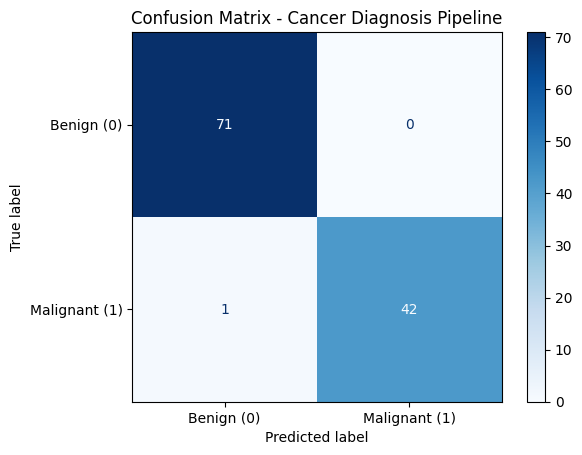

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# 1. Generate predictions on test data
ypred = pipe.predict(xtest)

# 2. Compute raw confusion matrix
cm = confusion_matrix(ytest, ypred)
print("Confusion Matrix:\n", cm)

# 3. Print detailed classification metrics (Precision, Recall, F1-score)
print("\nClassification Report:\n")
print(
    classification_report(
        ytest, ypred, target_names=["Benign (0)", "Malignant (1)"]
    )
)

# 4. Plot visual confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Benign (0)", "Malignant (1)"]
)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix - Cancer Diagnosis Pipeline")
plt.grid(False)
plt.show()

(114,)

In [45]:
# Identify the exact index where the model failed
probs = pipe.predict_proba(xtest)[:, 1]
misclassified = xtest[ytest != (probs >= 0.5)]

print("Misclassified True Label:", ytest[ytest != (probs >= 0.5)].values)
print("Predicted Malignant Probability:", probs[ytest != (probs >= 0.5)])

Misclassified True Label: [1]
Predicted Malignant Probability: [0.07487336]


In [58]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, x, y, cv=cv, scoring='accuracy')

print(f"Mean CV Accuracy: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")

Mean CV Accuracy: 97.37% (+/- 1.24%)
